In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('data/Student_Performance.csv')
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  str    
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), str(1)
memory usage: 468.9 KB


Let's plot our dependent variable against all the independent variables

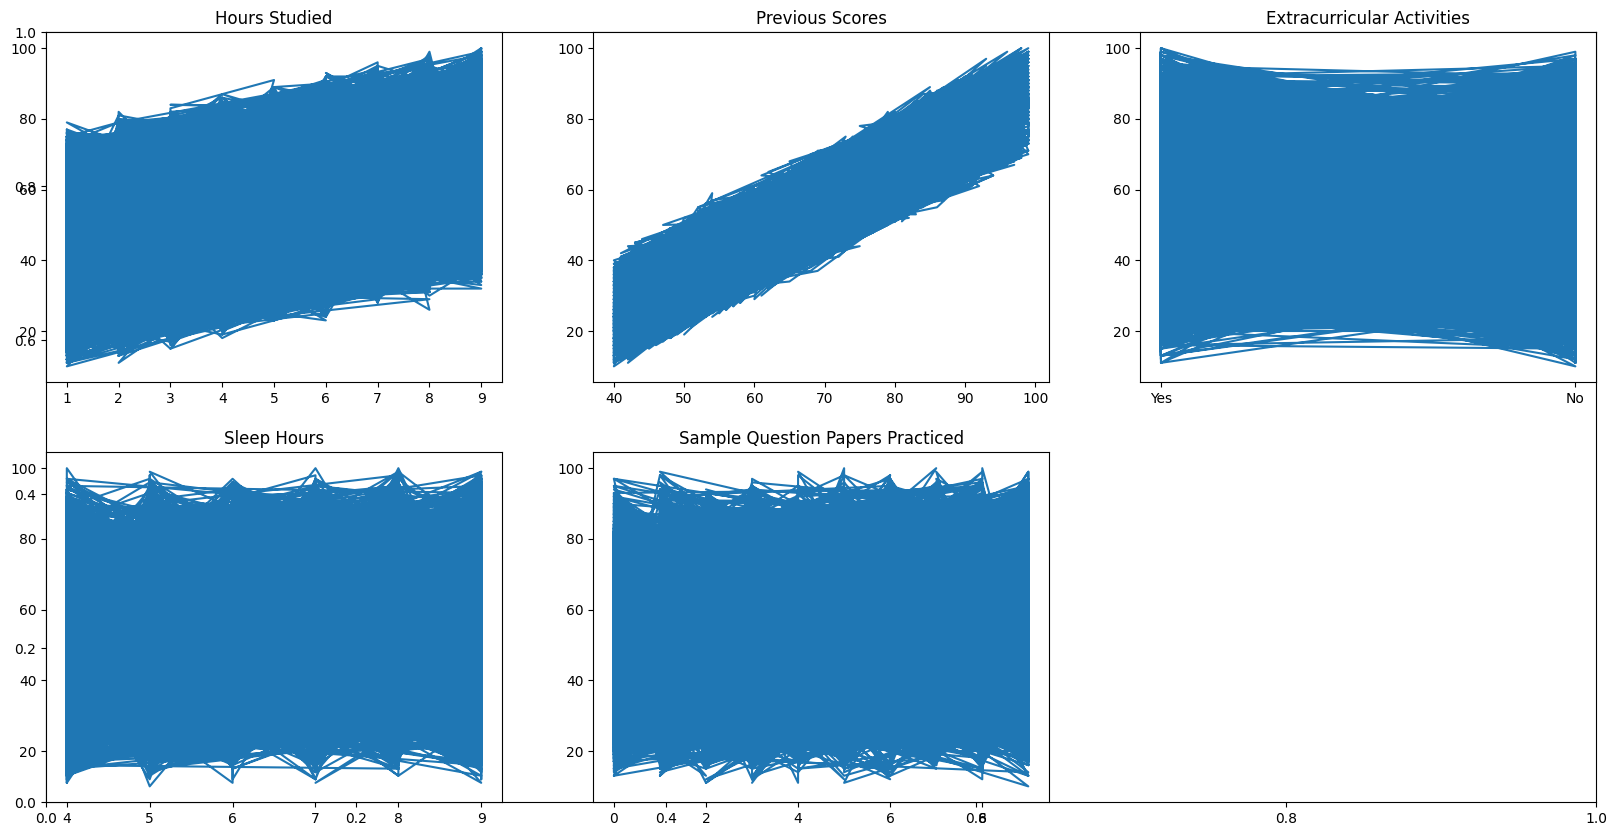

In [4]:
features = ['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced']

plt.subplots(figsize=(20,10))

for i, col in enumerate(features):
  plt.subplot(2,3,i+1)
  plt.title(features[i])
  plt.plot(df[col], df['Performance Index'])
plt.show()

We can kind of see what already has a clear linear trend. Let's also put them in a scatter to compare

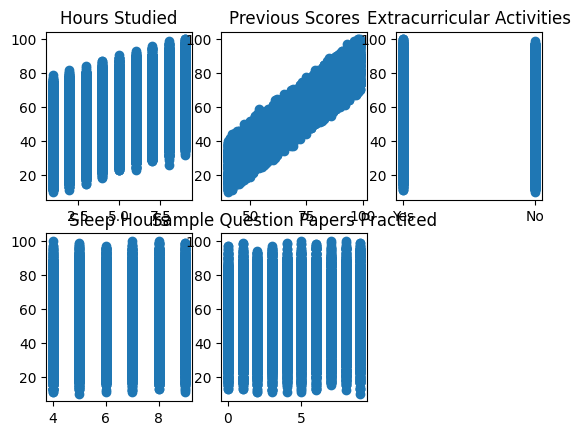

In [5]:
for i, col in enumerate(features):
  plt.subplot(2,3,i+1)
  plt.title(features[i])
  plt.scatter(df[col], df['Performance Index'])
plt.show()

We need to convert our Extracurricular Activities column to be a boolean instead of a string for it to be usable by our model. It is also worth noting that we just pass through our different indpendent variables as part of a list in order to use them all

In [6]:
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes': True, 'No': False})
X = df[['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced']]
y = df['Performance Index']

In [7]:
regr = LinearRegression()
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)
regr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


If we try to plot our graph against one of the independent variables we get something quite messy. This is because our fit is for multiple variables which is not something we can really visualise as it is multi-dimensional as opposed to our normal 2D graphs

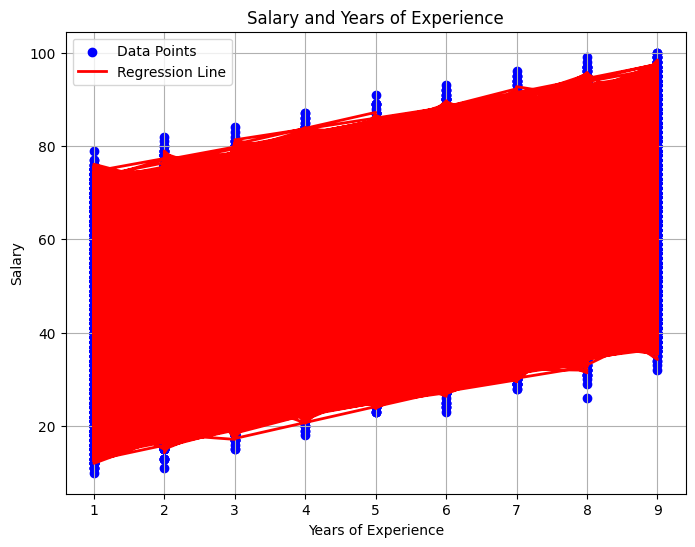

In [8]:
y_pred = regr.predict(X)
plt.figure(figsize=(8,6)) 
plt.scatter(df['Hours Studied'], y, color='blue', label='Data Points') 
plt.plot(df['Hours Studied'], y_pred, color='red', linewidth=2, label='Regression Line') 
plt.title('Salary and Years of Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()

We can check our r2 scores to find out whether our model is a good fit

In [9]:
r2_train = r2_score(y_train, regr.predict(x_train))

print(r2_train)

0.9889033042773491


In [10]:
r2_test = r2_score(y_test, regr.predict(x_test))

print(r2_test)

0.9880686410711422


Now we can make predictions based on model. Make sure to put things in the right order - hours studied, previous marks, extracurricular acitivities, hours of sleep, sample question papers practiced

In [14]:
single_pred = regr.predict([[5, 80, True, 8, 3]])
print(single_pred)

[66.73693965]


C:\Users\rmcdermott17\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
